# **Name:** Ahmed Huzaifa Malik
# **Ref - ID:** TC-INT-20260603-527

# **Task (1) - Customer Behavior Analytics & Churn Prediction Dashboard**

# **Dataset Loading**

In [3]:
# Importing required libraries for data exploration and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# Load the dataset
df = pd.read_csv("Telco-Customer-Churn.csv")

# Display the dataet
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No        

# **Data Exploration**

In [5]:
# Shape of the datset
print(df.shape)

(7043, 21)


In [6]:
# Basic info of the dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
# Class balance check
print(df['Churn'].value_counts(normalize=True))

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [10]:
# TotalCharges: coerce to numeric, blanks -> NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing TotalCharges:", df['TotalCharges'].isna().sum())

Missing TotalCharges: 11


In [11]:
# These 11 rows all have tenure == 0 (brand-new customers). Logical fill: 0, because a tenure-0 customer hasn't been billed a cumulative total yet.
df.loc[df['tenure'] == 0, 'TotalCharges'] = 0.0

# Safety net for any other NaN:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [12]:
# Drop ID (not a feature)
df = df.drop(columns=['customerID'])

In [13]:
# Outlier check on numeric cols (don't blindly remove — these are legitimate)
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
print(df[num_cols].describe())

            tenure  MonthlyCharges  TotalCharges
count  7043.000000     7043.000000   7043.000000
mean     32.371149       64.761692   2279.734304
std      24.559481       30.090047   2266.794470
min       0.000000       18.250000      0.000000
25%       9.000000       35.500000    398.550000
50%      29.000000       70.350000   1394.550000
75%      55.000000       89.850000   3786.600000
max      72.000000      118.750000   8684.800000


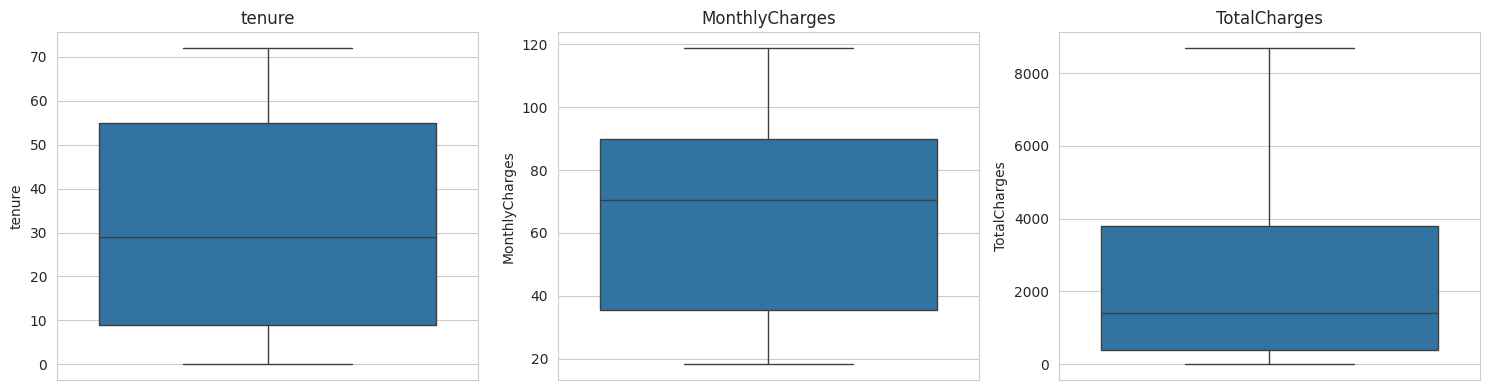

In [14]:
# Box plot for outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, c in zip(axes, num_cols):
    sns.boxplot(y=df[c], ax=ax); ax.set_title(c)
plt.tight_layout(); plt.show()

# **Feature Engineering**

In [15]:
# Convert target
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

In [16]:
# 1. Tenure buckets
df['tenure_group'] = pd.cut(df['tenure'], bins=[-1,12,24,48,60,np.inf],
                            labels=['0-1yr','1-2yr','2-4yr','4-5yr','5yr+'])

In [17]:
# 2. Count of add-on services subscribed (proxy for engagement)
service_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection',
                'TechSupport','StreamingTV','StreamingMovies']

In [18]:
df['num_services'] = (df[service_cols] == 'Yes').sum(axis=1)

In [19]:
# 3. Charge ratio: avg monthly spend over lifetime vs current monthly
df['avg_monthly_total'] = df['TotalCharges'] / df['tenure'].replace(0, 1)
df['charge_ratio'] = df['MonthlyCharges'] / df['avg_monthly_total'].replace(0, 1)

In [20]:
# 4. Auto-pay flag (electronic/auto methods correlate with retention)
df['auto_payment'] = df['PaymentMethod'].str.contains('automatic').astype(int)

In [21]:
# 5. Monthly contract flag (strongest churn driver in this dataset)
df['is_monthly'] = (df['Contract'] == 'Month-to-month').astype(int)

# **Data Visualization**

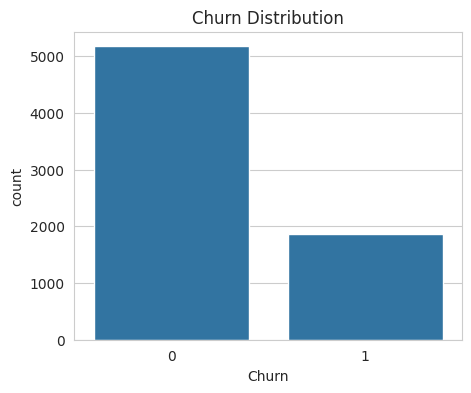

In [22]:
# Churn distribution
plt.figure(figsize=(5,4))
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

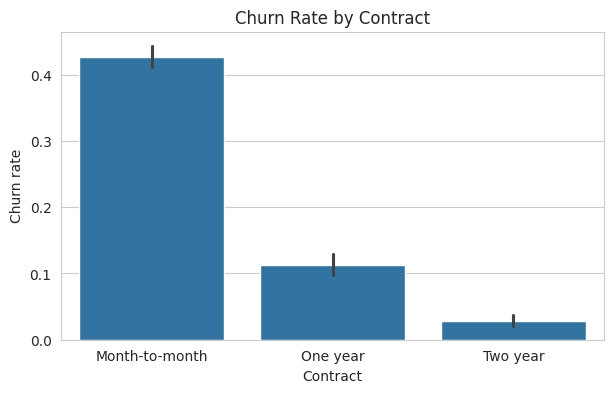

In [24]:
# Churn by contract type
plt.figure(figsize=(7,4))
sns.barplot(x='Contract', y='Churn', data=df)
plt.title('Churn Rate by Contract')
plt.ylabel('Churn rate')
plt.show()

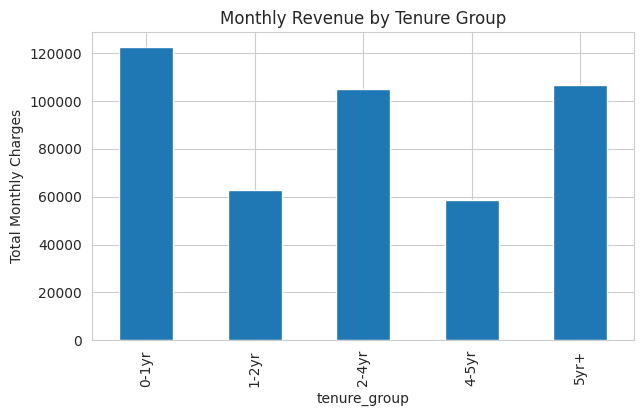

In [25]:
# "Revenue" by segment (snapshot, NOT a time trend — no dates in data)
plt.figure(figsize=(7,4))
df.groupby('tenure_group', observed=True)['MonthlyCharges'].sum().plot(kind='bar')
plt.title('Monthly Revenue by Tenure Group')
plt.ylabel('Total Monthly Charges')
plt.show()

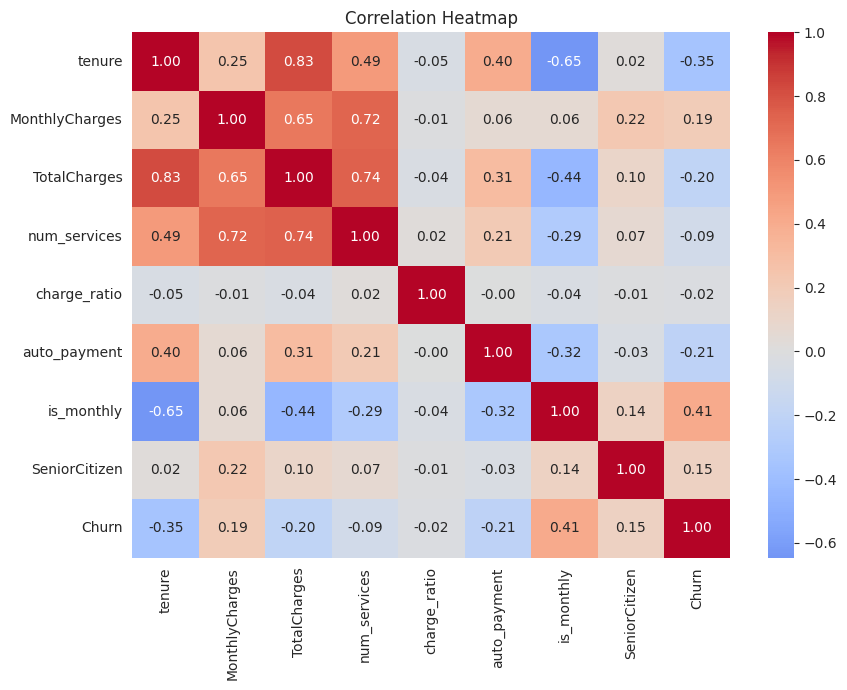

In [26]:
# Correlation heatmap (numeric + engineered)
plt.figure(figsize=(9,7))
corr_cols = ['tenure','MonthlyCharges','TotalCharges','num_services',
             'charge_ratio','auto_payment','is_monthly','SeniorCitizen','Churn']
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# **Data Encoding and Spliting**

In [27]:
# Importing the required libraries for the process
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [28]:
# Dropping the categorical and generating dummies
model_df = df.drop(columns=['tenure_group'])
model_df = pd.get_dummies(model_df, drop_first=True)

In [29]:
# Splitting the data using train-test split
X = model_df.drop(columns=['Churn'])
y = model_df['Churn']

In [30]:
# Initializing and stratifying the imbalanced target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [31]:
# Scaling and transforming the splitted data
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# **Model Training**

In [32]:
# Importing the required models and associated metrics
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

In [33]:
# class_weight='balanced' because 26.5% churn, without it recall on churners is poor
logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg.fit(X_train_s, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [34]:
# Training random forest
rf = RandomForestClassifier(n_estimators=300, max_depth=10,
                            class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=300,
                       random_state=42)

In [35]:
# Training XGBoost
from xgboost import XGBClassifier
scale = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                    scale_pos_weight=scale, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

# **Model Evaluation**

In [36]:
# Evaluation function
def evaluate(name, model, Xte, yte):
    pred = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]
    print(f"\n=== {name} ===")
    print(f"Accuracy : {accuracy_score(yte, pred):.3f}")
    print(f"Precision: {precision_score(yte, pred):.3f}")
    print(f"Recall   : {recall_score(yte, pred):.3f}")
    print(f"F1       : {f1_score(yte, pred):.3f}")
    print(f"ROC-AUC  : {roc_auc_score(yte, proba):.3f}")
    print(classification_report(yte, pred))
    return proba

# Evaluationg models
p_lr = evaluate("Logistic Regression", logreg, X_test_s, y_test)
p_rf = evaluate("Random Forest", rf, X_test, y_test)
p_xgb = evaluate("XGBoost", xgb, X_test, y_test)


=== Logistic Regression ===
Accuracy : 0.740
Precision: 0.507
Recall   : 0.783
F1       : 0.616
ROC-AUC  : 0.841
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


=== Random Forest ===
Accuracy : 0.769
Precision: 0.549
Recall   : 0.730
F1       : 0.627
ROC-AUC  : 0.840
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1035
           1       0.55      0.73      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409


=== XGBoost ===
Accuracy : 0.770
Precision: 0.551
Recall   : 0.727
F1       : 0.627
ROC-AUC  : 0.827
              precisio

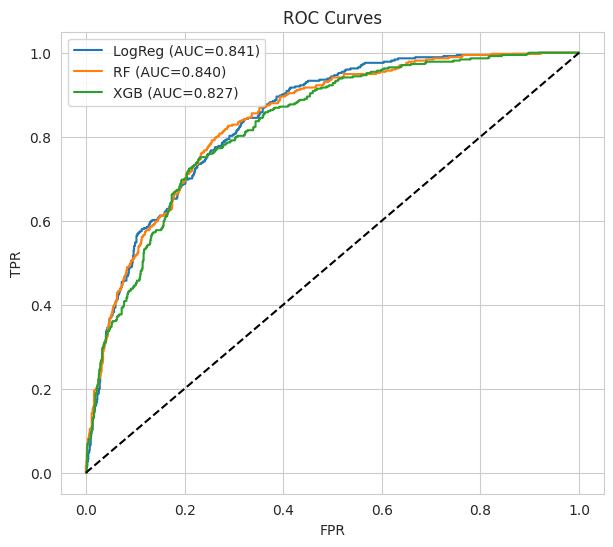

In [42]:
# ROC Curves
plt.figure(figsize=(7,6))
for name, p in [("LogReg", p_lr), ("RF", p_rf)] + ([("XGB", p_xgb)]):
    fpr, tpr, _ = roc_curve(y_test, p)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test,p):.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curves')
plt.legend()
plt.show()

# **Customer Segmentation**

In [39]:
# Value = total revenue contribution, use TotalCharges as lifetime value proxy.
df['value_segment'] = pd.qcut(df['TotalCharges'], q=3,
                              labels=['Low value','Medium value','High value'])
print(df.groupby('value_segment', observed=True).agg(
    customers=('Churn','size'),
    churn_rate=('Churn','mean'),
    avg_monthly=('MonthlyCharges','mean')))

               customers  churn_rate  avg_monthly
value_segment                                    
Low value           2348    0.393526    47.455771
Medium value        2347    0.237324    57.348402
High value          2348    0.165247    89.477747


# **Churn Probability and Risk Category**

In [49]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, logreg.predict(X_test_s)))

[[750 285]
 [ 81 293]]


In [53]:
coefs = pd.Series(logreg.coef_[0], index=X.columns).sort_values()
print("Pushes toward churn (largest positive):")
print(coefs.tail(10))
print("\nPushes against churn (largest negative):")
print(coefs.head(10))

Pushes toward churn (largest positive):
SeniorCitizen                     0.056489
num_services                      0.089702
PaymentMethod_Electronic check    0.117026
PaperlessBilling_Yes              0.164152
MultipleLines_Yes                 0.207632
StreamingTV_Yes                   0.259744
StreamingMovies_Yes               0.270568
is_monthly                        0.319366
TotalCharges                      0.492431
InternetService_Fiber optic       0.833426
dtype: float64

Pushes against churn (largest negative):
tenure                               -1.161442
MonthlyCharges                       -0.919399
charge_ratio                         -0.429345
Contract_Two year                    -0.337716
avg_monthly_total                    -0.178978
OnlineSecurity_Yes                   -0.131072
Dependents_Yes                       -0.103198
OnlineSecurity_No internet service   -0.101723
OnlineBackup_No internet service     -0.101723
StreamingTV_No internet service      -0.101723
dty

In [55]:
best_model = logreg
best_X = X_test_s
df_test = X_test.copy()
df_test['churn_probability'] = best_model.predict_proba(best_X)[:, 1]
df_test['risk_category'] = pd.cut(df_test['churn_probability'],
                                  bins=[-0.01,0.33,0.66,1.0], labels=['Low','Medium','High'])
print(df_test['risk_category'].value_counts())

risk_category
Low       629
High      428
Medium    352
Name: count, dtype: int64


In [57]:
# Drivers from the chosen model
coefs = pd.Series(logreg.coef_[0], index=X.columns).sort_values()
print("Top churn-raising drivers (LogReg):")
print(coefs.tail(10))

# Revenue at risk
high_risk_idx = df_test[df_test['risk_category']=='High'].index
print(f"\nMonthly revenue at risk: ${df.loc[high_risk_idx, 'MonthlyCharges'].sum():,.2f}")

Top churn-raising drivers (LogReg):
SeniorCitizen                     0.056489
num_services                      0.089702
PaymentMethod_Electronic check    0.117026
PaperlessBilling_Yes              0.164152
MultipleLines_Yes                 0.207632
StreamingTV_Yes                   0.259744
StreamingMovies_Yes               0.270568
is_monthly                        0.319366
TotalCharges                      0.492431
InternetService_Fiber optic       0.833426
dtype: float64

Monthly revenue at risk: $33,545.30


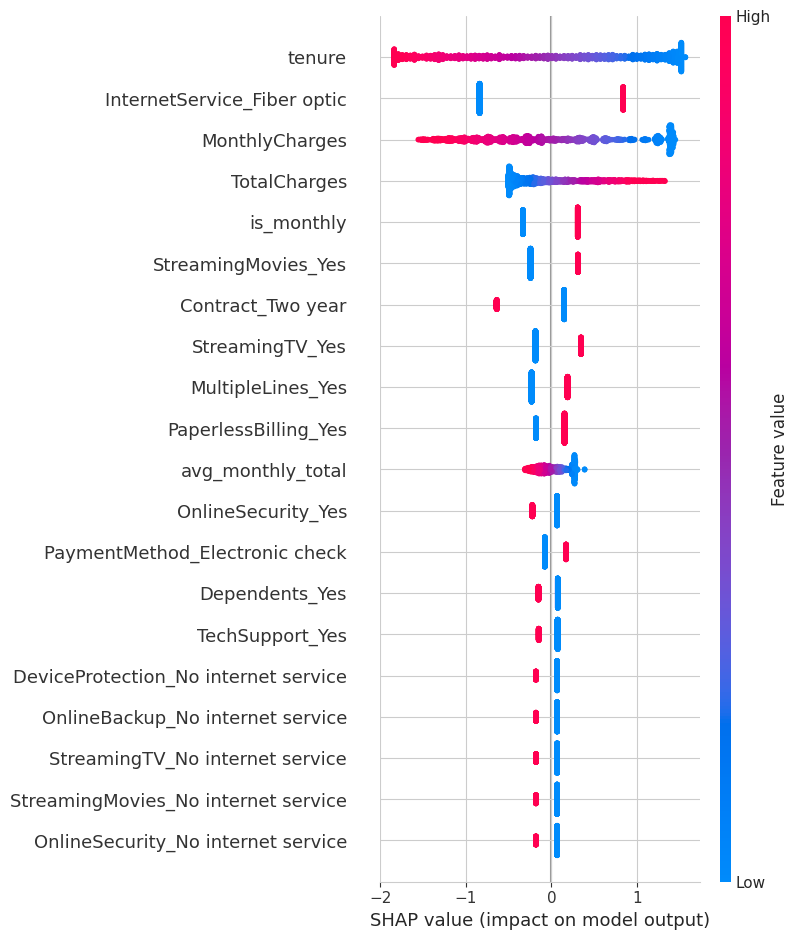

In [59]:
# Import shap
import shap

# LinearExplainer for logistic regression; uses the SCALED training data
explainer = shap.LinearExplainer(logreg, X_train_s)
shap_values = explainer.shap_values(X_test_s)
shap.summary_plot(shap_values, X_test_s, feature_names=list(X.columns))

In [60]:
# Save model, scaled and columns data
import joblib
joblib.dump(logreg, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X.columns), 'columns.pkl')

from google.colab import files
files.download('model.pkl')
files.download('scaler.pkl')
files.download('columns.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>